# Práctica 1: Análsiis y Preprocesamiento de Datos

## Dataset de Novel de Obsesidad

El dataset **“Estimation of Obesity Levels Based on Eating Habits and Physical Condition”** reúne información de 2.111 individuos de México, Perú y Colombia. El objetivo es predecir el nivel de obesidad de cada persona a partir de hábitos alimenticios, características físicas y estilo de vida.

El conjunto contiene **17 atributos** (16 predictivos y 1 variable objetivo) que abarcan aspectos relacionados con la edad, el peso, la estatura, los antecedentes familiares, el consumo de ciertos alimentos y bebidas, el uso de tecnología, la actividad física y los medios de transporte. El nivel de obesidad está clasificado en siete categorías, que van desde “peso insuficiente” hasta “obesidad tipo III”.

| Atributo | Descripción |
|----------|-------------|
| Gender | Género del individuo (Male/Female) |
| Age | Edad en años |
| Height | Altura en metros |
| Weight | Peso en kilogramos |
| family_history_with_overweight | Si tiene antecedentes familiares de sobrepeso |
| FAVC | Frecuencia de consumo de alimentos con alto contenido calórico |
| FCVC | Frecuencia de consumo de vegetales (1 a 3) |
| NCP | Número de comidas principales al día |
| CAEC | Consumo de alimentos entre comidas (no, Sometimes, Frequently, Always) |
| SMOKE | Si fuma o no |
| CH2O | Consumo de agua diario en litros |
| SCC | Si controla el consumo de calorías |
| FAF | Frecuencia de actividad física (horas/semana) |
| TUE | Tiempo de uso de dispositivos electrónicos (horas/día) |
| CALC | Consumo de alcohol (no, Sometimes, Frequently, Always) |
| MTRANS | Medio de transporte principal (Automobile, Bike, Motorbike, Public_Transportation, Walking) |
| NObesity (Target) | Nivel de obesidad (Insufficient_Weight, Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III) |

### Ejercicio 1

Complete la tabla indicando cuántos atributos corresponden a cada del dataset de obesidad.

| Tipo de atributo | Cantidad | Atributo |
|-----------------|----------|-----------|
| Cuantitativo o numérico - Discreto| 1 | Age |
| Cuantitativo o numérico - Continuo | 7 | Height, Weight, FCVC, NCP, CH2O, FAF y TUE |
| Cualitativo o categórico - Nominal | 6 | Gender, family_history_with_overweight, FAVC, SMOKE, SCC y MTRANS |
| Cualitativo o categórico - Ordinal | 3 | CAEC, CALC y NObesity |

### Ejercicio 2 

Proponga una tarea de clasificación y una tarea de regresión que puedan realizarse a partir de los datos del dataset de obesidad.

### Respuesta

Una tarea de **clasificación** podría ser que a partir de todos los atributos se pueda clasificar y predecir el nivel de obesidad de un individuo (Insufficient_Weight, Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III).

Una tarea de **regresión** podría ser que a partir de todos los atributos (menos el peso) se pueda predecir el peso de un individuo.

### Ejercicio 3

Indique qué tipo de información brindan las siguientes representaciones gráficas: 
1. Diagrama de Barras  
2. Histograma
3. Diagrama de caja
4. Diagrama de dispersión 

Luego, genere al menos un ejemplo de cada representación usando el dataset de obesidad y explique cómo interpretar cada uno.

### Respuestas

1. Un **Diagrama de Barras** sirve para mostrar **comparaciones** entre categorías, es mejor usarlo cuando se tienen **datos cualitativos o discretos**.
2. Un **Histograma** sirve para ver la **distribución de frecuencias** de datos continuos, es mejor usarlo cuando se quiere ver **cómo se distribuyen los datos** (de forma simétrica, sesgada, normal, etc.).
3. Un **Diagrama de Caja** sirve para ver los **cuartiles, la mediana y los valores atípicos**, es mejor usarlo cuando se quiere analizar la **dispersión y simetría de los datos**, o comparar distribuciones entre grupos.
4. Un **Diagrama de Dispersión** sirve para ver la **relación** entre 2 variables numéricas, es mejor usarlo para analizar **correlaciones** o **tendencias** entre dos variables.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# nos traemos el csv (ni ruta tenía el chabon)
df = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\ObesityDataSet_raw_and_data_sinthetic.csv")

#chequeamos que esté bien
df.head()    # vemos las primeras filas
df.shape    # vemos cantidad de filas y columnas
df.info()     # vemos tipos de datos
df.describe() # vemos estadísticas de las columnas numéricas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


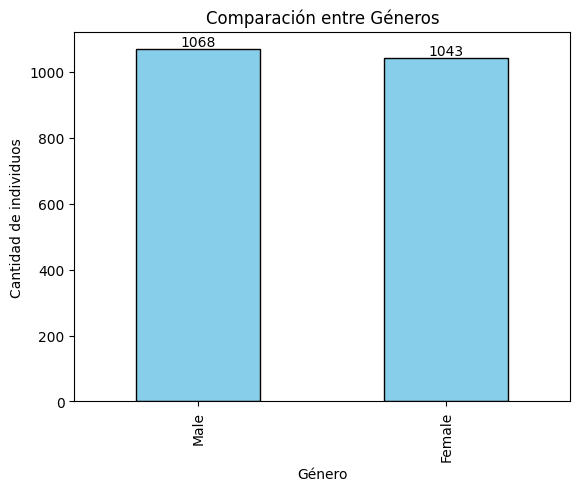

In [2]:
# Vamos a hacer un Diagrama de Barras para ver una comparación entre los Géneros

# Calculamos la Frecuencia de cada género
frecuencia_por_gen = df["Gender"].value_counts()

# Creamos el gráfico
ax = frecuencia_por_gen.plot(kind="bar", color="skyblue", edgecolor="black")

# Título y etiquetas de ejes
plt.title("Comparación entre Géneros")
plt.xlabel("Género")
plt.ylabel("Cantidad de individuos")

# Agregamos los valores exactos encima de las barras
for barra, cantidad in enumerate(frecuencia_por_gen):
    plt.text(barra,          # pos de la barra en el eje 
             cantidad,       # cantidad por barra
             str(cantidad), 
             ha='center',    # centramos texto
             va='bottom')    # ponemos el teto arriba de la barra

plt.show()

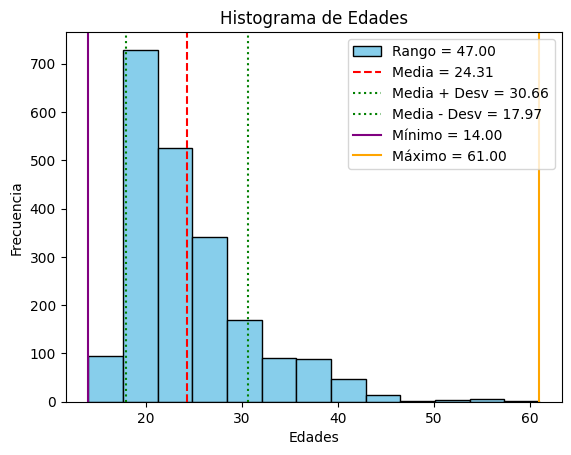

In [3]:
# Vamos a hacer un Histograma para ver la distribución de frecuencias por Edad

edades = df["Age"]

# Calculamos estadísticas
media = edades.mean()
desv = edades.std()
minimo = edades.min()
maximo = edades.max()
rango = maximo - minimo

# Graficamos histograma
plt.hist(edades, 
         bins="sturges",           # dejamos que calcule la cantidad de barras
         edgecolor='black', 
         color="skyblue",
         label=f"Rango = {rango:.2f}")
plt.title("Histograma de Edades")
plt.xlabel("Edades")
plt.ylabel("Frecuencia")

# Líneas de referencia
plt.axvline(media,                                        # graficamos la media
            color='red',                                  # color de la línea
            linestyle='--',                               # estilo de la línea
            linewidth=1.5,                                # ancho de la linea
            label=f"Media = {media:.2f}")                 # destinamos 2 decimales
plt.axvline(media + desv,                                 # desviación a la derecha
            color='green', 
            linestyle=':', 
            linewidth=1.5, 
            label=f"Media + Desv = {media+desv:.2f}")
plt.axvline(media - desv,                                 # desviación a la izquierda
            color='green', 
            linestyle=':', 
            linewidth=1.5, 
            label=f"Media - Desv = {media-desv:.2f}")
plt.axvline(minimo,                                       # mínimo
            color='purple', 
            linestyle='-', 
            linewidth=1.5, 
            label=f"Mínimo = {minimo:.2f}")
plt.axvline(maximo,                                       # máximo
            color='orange', 
            linestyle='-', 
            linewidth=1.5, 
            label=f"Máximo = {maximo:.2f}")

# Mostrar leyenda
plt.legend()

plt.show()

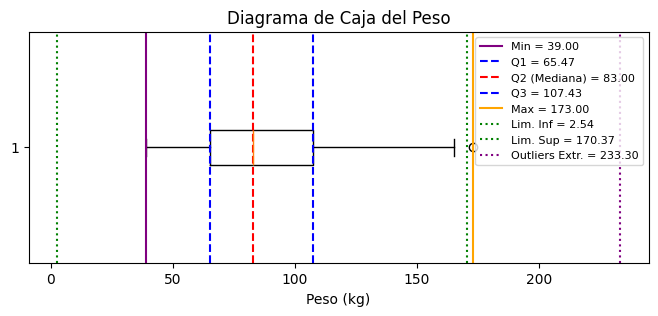

In [4]:
# Vamos a hacer un Diagrama de Cajas para ver la Dispersión y Simetría de los Pesos de los Individuos

pesos = df["Weight"]

# Calcular estadísticos
q1 = pesos.quantile(0.25)         # sacamos el Q1
q2 = pesos.quantile(0.5)          # el Q2 es la mediana
q3 = pesos.quantile(0.75)         # sacamos el Q3
ric = q3 - q1
minimo = pesos.min()
maximo = pesos.max()
lim_inf = q1 - 1.5 * ric
lim_sup = q3 + 1.5 * ric
atipicos_extremos = q3 + 3 * ric

# Boxplot horizontal
plt.figure(figsize=(8,3))         # creamos una figura con ancho 8 y alto 3
plt.boxplot(pesos, 
            vert=False,           # ponemos la cajita horizontal
            patch_artist=False)   # hacemos que solo se vea el contorno de la caja

# Líneas de referencia
plt.axvline(minimo, 
            color='purple', 
            linestyle='-', 
            linewidth=1.5, 
            label=f"Min = {minimo:.2f}")
plt.axvline(q1, 
            color='blue', 
            linestyle='--', 
            linewidth=1.5, 
            label=f"Q1 = {q1:.2f}")
plt.axvline(q2, 
            color='red', 
            linestyle='--', 
            linewidth=1.5, 
            label=f"Q2 (Mediana) = {q2:.2f}")
plt.axvline(q3, 
            color='blue', 
            linestyle='--', 
            linewidth=1.5, 
            label=f"Q3 = {q3:.2f}")
plt.axvline(maximo, 
            color='orange', 
            linestyle='-', 
            linewidth=1.5, 
            label=f"Max = {maximo:.2f}")
plt.axvline(lim_inf, 
            color='green', 
            linestyle=':', 
            linewidth=1.5, 
            label=f"Lim. Inf = {lim_inf:.2f}")
plt.axvline(lim_sup, 
            color='green', 
            linestyle=':', 
            linewidth=1.5, 
            label=f"Lim. Sup = {lim_sup:.2f}")
plt.axvline(atipicos_extremos, 
            color='purple', 
            linestyle=':', 
            linewidth=1.5, 
            label=f"Outliers Extr. = {atipicos_extremos:.2f}")

# Leyenda y título
plt.title("Diagrama de Caja del Peso")
plt.xlabel("Peso (kg)")
plt.legend(loc='best', fontsize=8)

plt.show()


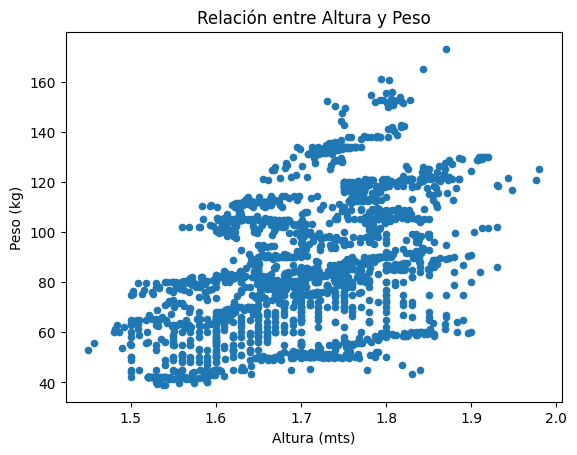

In [5]:
# Vamos a hacer un Diagrama de Dispersión para ver la relación entre las variables de Altura y Peso

# definimos el tipo de gráfico y las 2 variables a usar
df.plot(kind='scatter', x='Height', y='Weight')

plt.title("Relación entre Altura y Peso")
plt.xlabel("Altura (mts)")
plt.ylabel("Peso (kg)")
plt.show()

### Ejercicio 4 

Complete el siguiente cuadro y dibuje el diagrama de caja del atributo **“weight”**

| Medida | Valor |
|--------|-------|
| Mínimo | 39 |
| Máximo | 173 |
| Q1 | 65.47 |
| Q2 o mediana | 83 |
| Q3 | 107.43 |
| RIC | 41.95 |
| Bigote superior | 165.05 |
| Bigote inferior | 39 |
| Intervalos de valores atípicos leves | (170.37, 233.30] |
| Valores atípicos leves | 173 |
| Intervalos de valores atípicos extremos | Peso > 233.30 |
| Valores atípicos extremos  | No se encuentran valores |

### Calculamos nuevamente (El gráfico fue el que hice arriba)

In [6]:
# nos traemos los datos de los pesos
pesos = df["Weight"]

print("--------------------------DATA--------------------------")
print("Mínimo: ", pesos.min())
print("Máximo: ", pesos.max())
print("Q1: ", pesos.quantile(0.25))
print("Q2 o mediana: ", pesos.quantile(0.5))
print("Q3: ", pesos.quantile(0.75))
print("RIC: ", pesos.quantile(0.75) - pesos.quantile(0.25))
print("Bigote Superior: ", pesos[(pesos <= (pesos.quantile(0.75) + 1.5 * (pesos.quantile(0.75) - pesos.quantile(0.25))))].max())
print("Bigote Inferior: ", pesos.min())
print("Intervalos de valores atípicos leves: ", 
      f"({(pesos.quantile(0.75) + 1.5 * (pesos.quantile(0.75) - pesos.quantile(0.25))):.2f}, {(pesos.quantile(0.75) + 3 * (pesos.quantile(0.75) - pesos.quantile(0.25))):.2f}]")
print("Valores atípicos leves: ", pesos[(pesos >= 170.37) & (pesos < 233.30)].to_list())
print("Intervalos de valores atípicos extremos: ",
      f"Peso > {(pesos.quantile(0.75) + 3 * (pesos.quantile(0.75) - pesos.quantile(0.25))):.2f}")
print("Valores atípicos extremos: ", 
      pesos[(pesos > 233.30)].to_list() if pesos[(pesos > 233.30)].to_list() else "No se encuentran valores") 

--------------------------DATA--------------------------
Mínimo:  39.0
Máximo:  173.0
Q1:  65.473343
Q2 o mediana:  83.0
Q3:  107.430682
RIC:  41.957339000000005
Bigote Superior:  165.057269
Bigote Inferior:  39.0
Intervalos de valores atípicos leves:  (170.37, 233.30]
Valores atípicos leves:  [173.0]
Intervalos de valores atípicos extremos:  Peso > 233.30
Valores atípicos extremos:  No se encuentran valores


### Ejercicio 5

Los valores del atributo peso (**“weight”**) fueron agrupados según el atributo de antecedente de obesidad familiar (**“family_history_with_overweight”**). La figura muestra los diagramas de caja correspondientes.

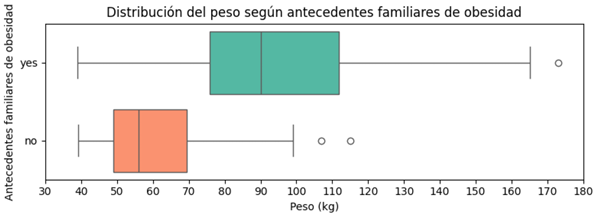

Complete el siguiente cuadro y responda verdadero o falso justificando cada afirmación según los valores obtenidos:

| Medida | yes | no |
|--------|-----|----|
| Mínimo | 39 | 39 |
| Máximo | 173 | 173 |
| Q1 | aprox. 75 | aprox. 49 |
| Q2 | 90 | aprox. 56 |
| Q3 | aprox. 112 | aprox. 69 |
| RIC | aprox. 37 | aprox. 20 |
| Bigote Inferior | 39 | 39 |
| Bigote Superior | aprox. 99 | aprox. 165 |

1. Al menos el 25% de las personas con antecedentes familiares de obesidad pesan más de 100 kg.
2. Es atípico que una persona sin antecedentes familiares de obesidad (no) pese más de 115 kg.
3. La mediana del peso de las personas sin antecedentes familiares (no) es menor que 60 kg.
4. Todos los valores atípicos para personas con antecedentes familiares de obesidad son leves.

### Verdadero y Falso

1. **VERDADERO**. Al Q3 valer aprox. 112 eso significa que hay un 25% de los datos que va a estar por encima de 112 kg.
2. **VERDADERO**. Lo atípico se empieza a considerar para ese gráfico desde todo $peso > Q3 + 1.5 \cdot RIC$, es decir, todo $peso > 99$. Por lo tanto sí, todo individuo que pese más de 115 kg será considerado atípico.
3. **VERDADERO**. La mediana o Q2 se ve en el gráfico como la raya vertical dentro de la caja, se ve que en el gráfico vale menos de 60.
4. **VERDADERO**. El valor atípico que se ve para ese gráfico coincide con el valor máximo, es decir, 173. Los valores atípicos leves son los que se encuentran en este rango $(Q3 + 1.5 \cdot RIC, Q3 + 3 \cdot RIC]$, es decir, el rango $(170.37, 233.30]$, 173 se encuentra en ese rango.

### Ejercicio 6

Discretice el atributo del consumo de agua diario en litros (**“CH2O”**) en tres intervalos: **Bajo, Medio y Alto**. Indique en la tabla los intervalos utilizados y la cantidad respectivas de ejemplos de cada uno al discretizar por rango y por intervalo. Luego, explique porque los ejemplos no quedaron divididos en intervalos con la misma cantidad de valores.

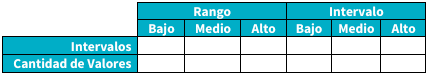

### Respuestas

Discretización por RANGO:
- Intervalos: Bajo (0,998, 1.667] ; Medio (1.667, 2333] ; Alto (2,333, 3.0]
- Cantidad de Valores: Bajo 576 ; Medio 910 ; Alto 625

Discretización por FRECUENCIA/INTERVALO:
- Intervalos: Bajo (0.999, 1.92] ; Medio (1.92, 2.185 ; Alto (2.185, 3.0]
- Cantidad de Valores: Bajo 704 ; Medio 703 ; Alto 704

La **discretización por rango** produce intervalos de igual tamaño en términos de valores, pero **no necesariamente igual número de datos**, porque los datos pueden estar distribuidos de forma desigual.

La **discretización por frecuencia** produce intervalos con **igual número de datos**, pero los rangos de valores pueden ser desiguales.

Esto nos hace ver que la distribución de los datos determina la cantidad de ejemplos por intervalo cuando se **discretiza por rango**, mientras que la **discretización por frecuencia** ajusta los intervalos para igualar la cantidad de ejemplos.

In [7]:
# Discretización por Rangos

# con el método "cut" hacemos que se dividan k intervalos de igual amplitud
# usa (Máximo - Mínimo) / k para calcular los tamaños de los intervalos
df["CH2O_rango"] = pd.cut(df["CH2O"],
                          bins=3,            # nro. de intervalos "k"     
                          labels=[           # etiquetas para los intervalos
                              "Bajo",
                              "Medio",
                              "Alto"
                          ]
                         )

# mostramos los valores observados para cada intervalo
print("----------POR RANGO----------")
print(df["CH2O_rango"].value_counts())

# Discretización Por Frecuencia

# con el método "qcut" se arman intervalos en base a la distribuvión real de los
# datos, se hace para que la cantidad de ejem. por categoría sea más pareja
# usa N / k para calcular los tamaños de los intervalos
df["CH2O_intervalo"] = pd.qcut(df["CH2O"],
                               q=3,
                              )

# mostramos los valores observados para cada intervalo
print("----------POR FRECUENCIA----------")
print(df["CH2O_intervalo"].value_counts())

----------POR RANGO----------
CH2O_rango
Medio    910
Alto     625
Bajo     576
Name: count, dtype: int64
----------POR FRECUENCIA----------
CH2O_intervalo
(0.999, 1.92]    704
(2.185, 3.0]     704
(1.92, 2.185]    703
Name: count, dtype: int64


## Dataset Titanic

El dataset del Titanic, es un conjunto de datos clásico utilizado para tareas de clasificación binaria. Se basa en información histórica de los pasajeros del RMS Titanic, que se hundió en 1912 tras chocar con un iceberg. El objetivo principal es predecir si un pasajero sobrevivió o no, basado en características como su clase social, edad, género y otros factores socioeconómicos. 

El RMS Titanic se hundió el 15 de abril de 1912 durante su viaje inaugural. De las aproximadamente 2,224 personas a bordo, más de 1,500 murieron, convirtiendo este evento en uno de los naufragios más mortíferos en tiempos de paz.

| Atributo     | Descripción                                                                 |
|--------------|-----------------------------------------------------------------------------|
| PassengerId  | Identificador único del pasajero                                             |
| Survived     | Variable objetivo: Indica si el pasajero sobrevivió (1) o no (0)           |
| Pclass       | Clase del ticket (proxy de estatus socioeconómico)                          |
| Name         | Nombre completo del pasajero, incluyendo títulos (ej. Mr., Mrs.)            |
| Sex          | Género del pasajero (male, female)                                          |
| Age          | Edad en años (puede ser fraccional para niños)                              |
| SibSp        | Número de hermanos/esposos a bordo                                         |
| Parch        | Número de padres/hijos a bordo                                             |
| Ticket       | Número del ticket                                                          |
| Fare         | Tarifa pagada por el ticket                                                |
| Cabin        | Número de cabina (muchos faltantes)                                        |
| Embarked     | Puerto de embarque (C, Q, S)                                              |


### Ejercicio 7

Realice las siguientes tareas para preparar el dataset para que pueda ser utilizado para entrenar modelos de redes neuronales.

1. Visualice las primeras 5 filas y el resumen estadístico.
2. Identifique los atributos (columnas) con valores nulos y su porcentaje.
3. Analizar los valores faltantes y discutir cuales serían las alternativas posibles para tratarlos.
4. Los nombres de los pasajeros van acompañados de títulos que pueden ser importantes para la interpretación de los datos o para completar información faltante:
   1. Extrae el título (como Mr, Miss, Mrs, Master, etc.) del nombre de cada pasajero y crea una nueva columna llamada **Title**.
   2. Unifica los valores para que queden **Mr, Miss** (Mlle, Ms), **Mrs** (Mme), **Master, Others** (resto).
   3. Computa las edades faltantes utilizando la edad promedio por categoría. 
5. Complete los valores faltantes utilizando las estrategias planteadas en los puntos anteriores.
6. Cree un nuevo atributo **FamilySize** que contabiliza los integrantes de familia a partir de los atributos **SibSp** (hermanos y esposo) y **Parch** (padres e hijos). No olvidar contar a la persona.
7. Numerice los atributos categóricos: **Sex, Embarked, y Title**.
8. Discuta y responda ¿Por qué one-hot encoding podría ser preferible a label encoding para el atributo **Pclass**?
9. Visualiza distribuciones: Histograma de **Age**, gráfico de barras para **Survived** por **Sex y Pclass**.

### Respuestas

3. Cuando tratamos con **Valores faltantes** existen varias alternativas para tratarlos, entre ellas:
    - Ignorarlos.
    - Rellenarlos manualmente.
    - Usar una constante global para rellenarlos.
    - Usar el valor de la **Media** u otra medida de centralidad para rellenarlos.
    - Usar el valor de la **Media** u otra medida de centralidad de los objetos que pertenecen la misma clase.
    - Usar alguna técnica de **Aprendizaje Automático** para calcular el valor más probable.

Se detectan 3 columnas con valores faltantes:
- **Age:** Es un atributo importante ya que es un factor de supervivencia (no tendrían las mismas chances un señor de 80 años contra uno de 20), creo una opción rápida para rellenar los que faltan sería usar el valor de la media o de la mediana (la cosa es que si hay mucha variedad de edades no es muy bueno). Podríamos hacerlo más real si calculamos la media/mediana por ejemplo teniendo en cuenta las columnas **Pclass, Sex, o viendo el título en el Name**.
- **Cabin:** Acá tenemos más de un $77\%$ de nulos, quizás lo mejor sería eliminar la columna si es que no la tenemos que usar para nada o se puede dejar la columna pero agregar otra, por ejemplo, **Tiene_Cabina** donde apliquemos una **numeralización binaria** para dejar registrado si tenía o no Cabina asignada y después trabajar con esta nueva columna.
- **Embarked:** Solo hay 2 nulos, podemos ponerle la moda ya que es lo más común o volamos esas 2 filas.

8. Si usamos **Label Encoding** en **Pclass**, es decir, queda algo así: $Pclass: 1, 2, 3 → codificado\ como\ 0, 1, 2$ nos puede pasar que el modelo interprete que los números tienen un orden o magnitud entre ellos, pensando que tienen una **relación lineal** entre ellos. **One-Hot Encoding** nos convierte cada categoría en una columna binaria independiente, algo así haría:
| Pclass | Plclass_1 | Plclass_2 | Plclass_3 |
|--------|-----------|-----------|-----------|
| 1 | 1 | 0 | 0 |
| 2 | 0 | 1 | 0 |
| 3 | 0 | 0 | 1 |

    Esto hace que no haya un **orden implícito** y, por lo tanto, por más que haya una relación del tipo 1ª clase > 2ª clase > 3ª clase, no es estrictamente lineal y no lleva a malas interpretaciones por parte del modelo



--------------------PRIMERAS FILAS--------------------
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  


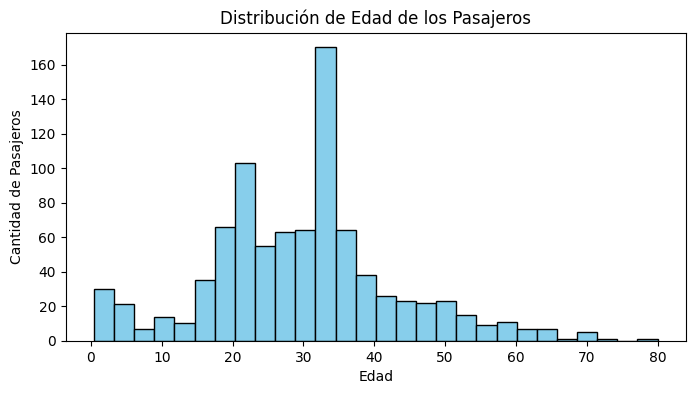

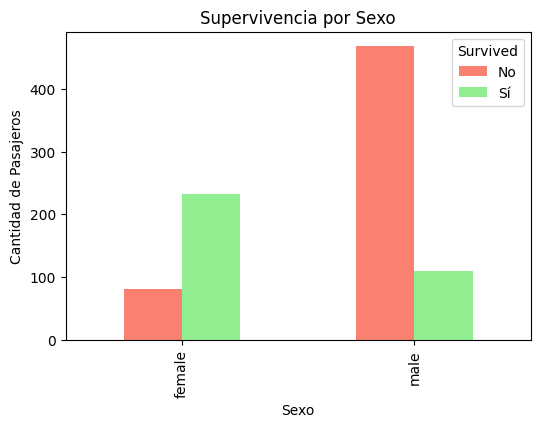

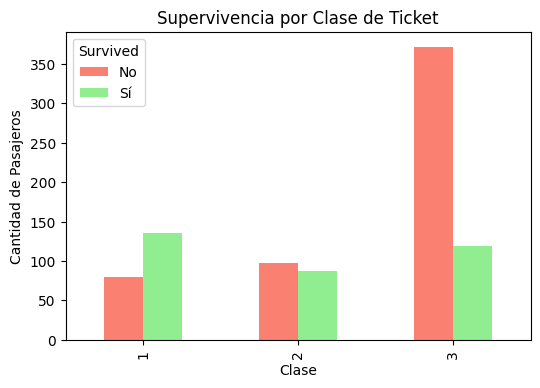

In [13]:
import re
from sklearn.preprocessing import LabelEncoder

# nos traemos el csv (ni ruta tenía el chabon x2)
df = pd.read_csv(r"C:\Users\Usuario\Desktop\FACULTAD\4to_Año\segundo_semestre\Aprendizaje Automatico Profundo\practicas\resoluciones\datasets\Titanic-Dataset.csv")

# 1. Visualice las primeras 5 filas y el resumen estadístico.

print("--------------------PRIMERAS FILAS--------------------")
print(df.head(5))    # vemos las primeras 5 filas
print("--------------------RESUMEN ESTADISTICO--------------------")
print(df.describe())    # vemos estadísticas de las columnas numéricas

# 2. Identifique los atributos (columnas) con valores nulos y su porcentaje.

nulos = df.isnull().sum()    # contamos los nulos por columna
porcentaje_nulos = (df.isnull().mean() * 100).round(2)    # calculamos el porcentaje de nulos
valores_nulos = pd.DataFrame({    # creamos un dataframe para mostrar la info
    "Valores Nulos": nulos,
    "Porcentaje (%)": porcentaje_nulos
})
print("--------------------NULOS Y PORCENTAJE--------------------")
print(valores_nulos)

# 4. Todos los incisos

# Extraemos el título del nombre, ",\s*([^\.]*)\." busca lo que está 
# entre la coma y el punto en el nombre  
df["Title"] = df["Name"].str.extract(r',\s*([^\.]*)\.', expand=False).str.strip()

# Unificamos los títulos
df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs',
    'Lady': 'Others',
    'Countess': 'Others',
    'Capt': 'Others',
    'Col': 'Others',
    'Don': 'Others',
    'Dr': 'Others',
    'Major': 'Others',
    'Rev': 'Others',
    'Sir': 'Others',
    'Jonkheer': 'Others',
    'Dona': 'Others'
})

# Rellenamos edades faltantes con la media de cada título
df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.mean()))

print("--------------------EJM CAMBIADOS--------------------")
print(df[['Name', 'Title', 'Age']].head(10))
print("--------------------NUEVA CANT NULOS EN EDAD--------------------")
print(df['Age'].isnull().sum())

# 5. Complete los valores faltantes utilizando las estrategias planteadas en los puntos anteriores.

# Age - Mediana agrupada por Pclass, Sex y Title
df['Age'] = df.groupby(['Pclass', 'Sex', 'Title'])['Age'].transform(lambda x: x.fillna(x.median()))

# Cabin - Nueva variable binaria: 1 si tiene cabina registrada, 0 si no
df['CabinKnown'] = df['Cabin'].notnull().astype(int)

# Embarked - Moda 
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print("--------------------NULOS RESTANTES--------------------")
print(df.isnull().sum())

# 6. Cree un nuevo atributo **FamilySize** que contabiliza los integrantes 
# de familia a partir de los atributos **SibSp** (hermanos y esposo) y **Parch** 
# (padres e hijos). No olvidar contar a la persona.

# Crear FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
print("--------------------EJM FAMILY SIZE--------------------")
print(df[['SibSp', 'Parch', 'FamilySize']].head(10))

# 7. Numerice los atributos categóricos: **Sex, Embarked, y Title**.

# Creamos los codificadores
le_sex = LabelEncoder()    # esta funcion convierte cada cat. a un núm. entero
le_embarked = LabelEncoder()
le_title = LabelEncoder()

# Ajustamos y transformamos cada columna
df['Sex_n'] = le_sex.fit_transform(df['Sex'])    # esta funcion aprende las cat. y genera la codificacion
df['Embarked_n'] = le_embarked.fit_transform(df['Embarked'])
df['Title_n'] = le_title.fit_transform(df['Title'])

print("--------------------NUMERALIZACIONES--------------------")
print(df[['Sex', 'Sex_n', 'Embarked', 'Embarked_n', 'Title', 'Title_n']].head(10))

# Visualiza distribuciones: Histograma de Age, gráfico de barras para Survived por Sex y Pclass.

# Histograma de Age
plt.figure(figsize=(8,4))
plt.hist(df['Age'], bins="auto", color='skyblue', edgecolor='black')
plt.title("Distribución de Edad de los Pasajeros")
plt.xlabel("Edad")
plt.ylabel("Cantidad de Pasajeros")
plt.show()

# Gráfico de barras de Survived por Sex 
sex_survived = df.groupby(['Sex', 'Survived']).size().unstack()
sex_survived.plot(kind='bar', figsize=(6,4), color=['salmon', 'lightgreen'])
plt.title("Supervivencia por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Cantidad de Pasajeros")
plt.legend(title='Survived', labels=['No', 'Sí'])
plt.show()

# Gráfico de barras de Survived por Pclass
pclass_survived = df.groupby(['Pclass', 'Survived']).size().unstack()
pclass_survived.plot(kind='bar', figsize=(6,4), color=['salmon', 'lightgreen'])
plt.title("Supervivencia por Clase de Ticket")
plt.xlabel("Clase")
plt.ylabel("Cantidad de Pasajeros")
plt.legend(title='Survived', labels=['No', 'Sí'])
plt.show()

### Ejercicio 8 

Calcule la correlación lineal entre los atributos **“Fare”** (Tarifa) y **“PClass”** (clase del ticket). Indique la intensidad de la correlación (no hay correlación/débil/fuerte) y el tipo (positiva/negativa). Explique el significado del valor de correlación obtenido.

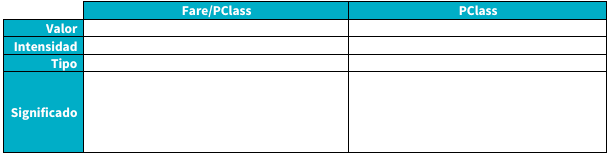

### Respuestas

Vamos a usar la fórmula $Corr(X,Y) = \frac{Cov(X,Y)}{\sigma_x \cdot \sigma_y}$ para sacar la correlación. Usamos el método **cov()** de pandas que nos ayuda calculando la **matriz de covarianza** entre las variables, en nuestro caso sería esta matriz:
| - | Fare | Pclass |
|---|------|--------|
| Fare | Var(Fare) | Cov(Fare, Pclass) |
| Pclass | Cov(Pclass, Fare) | Var(Pclass) |

despúes vamos a usar el método **loc()** para sacar el valor $Cov(Fare, Pclass)$ que es el que nos interesa.

**TABLA A COMPLETAR**
- Fare/PClass
  - Valor: -0.5494
  - Intensidad: Débil. $0.5 \leq |-0.5494| < 0.8$
  - Tipo: Negativa
  - Significado: Tenemos una correlación lineal débil y negativa entre la tarifa y la clase del ticket, los pasajeros de primera clase (**valor chico de PClass**) pagaron tarifas más altas (**valor grande de Fare**), mientras que los de tercera clase (**valor grande de PClass**) pagaron tarifas más baratas (**valor chico de Fare**)

In [14]:
X = df["Fare"]
Y = df["Pclass"]

# Calculamos covarianza
cov_matrix = df[["Fare", "Pclass"]].cov()
cov_xy = cov_matrix.loc["Fare", "Pclass"]

# Desviaciones estándar
sigma_x = X.std()
sigma_y = Y.std()

# Correlación usando la fórmula
corr_formula = cov_xy / (sigma_x * sigma_y)

print("Correlación (usando fórmula):", corr_formula)

Correlación (usando fórmula): -0.5494996199439081


### Ejercicio 9 

Realice un análisis sobre los valores de los atributos del dataset automobile.csv. Para cada atributo que no pueda ser procesado directamente, indique que problema tiene (valores nulos o vacíos, valores categóricos, valores atípicos o outliers, etc.) y como solucionarlo.

### Ejercicio 10

Dada la siguiente tabla con mediciones de 2 características correspondientes a mediciones de altura y peso de personas:

| Altura | 1.65 | 1.81 | 1.70 | 1.62 | 1.74 | 1.70 | 1.80 | 1.73 | 1.68 |
|--------|------|------|------|------|------|------|------|------|------|
| Peso | 75 | 86 | 82 | 78 | 77 | 87 | 90 | 83 | 80 |

1. Aplique las siguientes normalizaciones y grafíquelas con un diagrama de caja:
   - MinMax: $\frac{x_i-min(x)}{max(x)-min(x)}$
   - Standard: $\frac{x_i-media(x)}{stddev(x)}$
   - MinMax: $\frac{x_i-Q1(x)}{Q3(x)-Q1(x)}$
2. Agregue la siguiente medición $(2.20, 120)$ y repita el punto a)
3. Compare los diagramas de caja entre las normalizaciones de los puntos a) y b) y comente las diferencias. 